#ACTIVITY 1

##activity 1.1


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report, confusion_matrix

import warnings
import pickle
from scipy import stats

warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')

# Activity 1.2 - Reading and Understanding the Dataset

In this step, we load the insurance claims dataset and perform basic inspection to understand its structure, columns, data types, and missing values.

In [2]:
df = pd.read_csv("insurance_claims.csv")
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


## Basic Information and Structure

In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,0.0
mean,203.954000,38.948000,546238.648000,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103000,NaN
std,115.113174,9.140287,257063.005276,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861,NaN
min,0.000000,19.000000,100804.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.000000,NaN
25%,115.750000,32.000000,335980.250000,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.000000,NaN
50%,199.500000,38.000000,533135.000000,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.000000,NaN
75%,276.250000,44.000000,759099.750000,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.000000,NaN
max,479.000000,64.000000,999435.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.000000,NaN


## Checking Missing Values and Target Distribution

In [4]:
df.isin(['?']).sum()

df.replace('?', np.nan, inplace=True)
df.isna().sum()

df['fraud_reported'].value_counts()

,count
fraud_reported,
N,753
Y,247


In [5]:
df['fraud_reported'] = df['fraud_reported'].map({'Y':1, 'N':0})

#EPIC 3



# Story 2.1 - Univariate Analysis

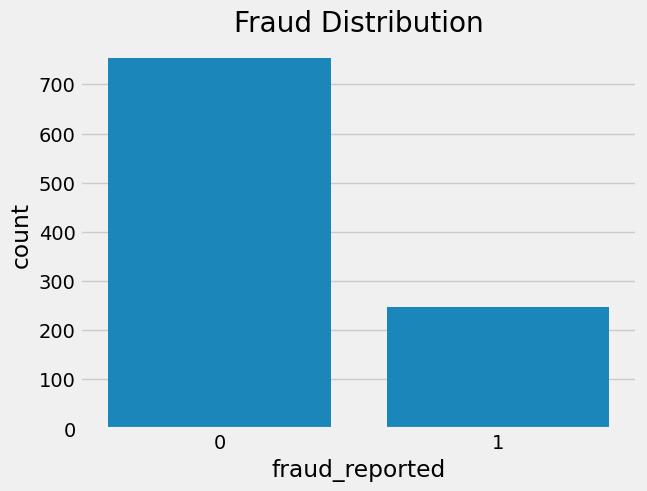

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='fraud_reported', data=df)
plt.title("Fraud Distribution")
plt.show()

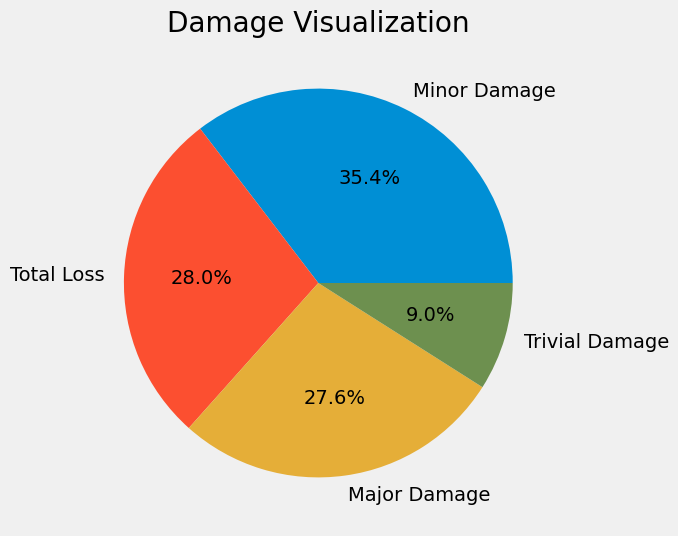

In [7]:
df['incident_severity'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Damage Visualization")
plt.ylabel("")
plt.show()

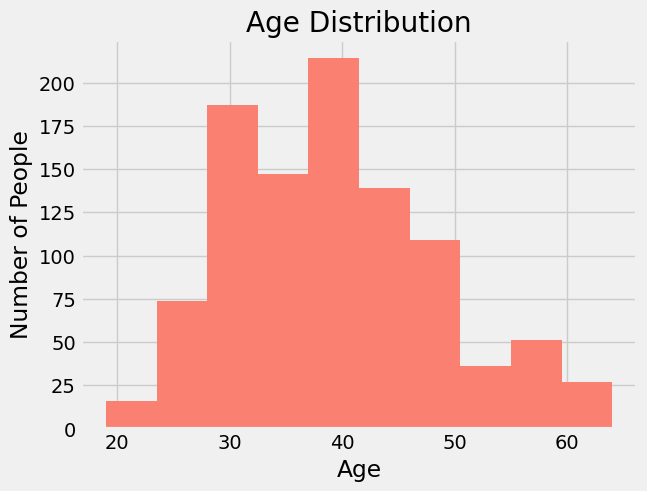

In [8]:
plt.hist(df['age'], bins=10, color='salmon')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of People")
plt.show()

# Story 2.3 - Multivariate Analysis

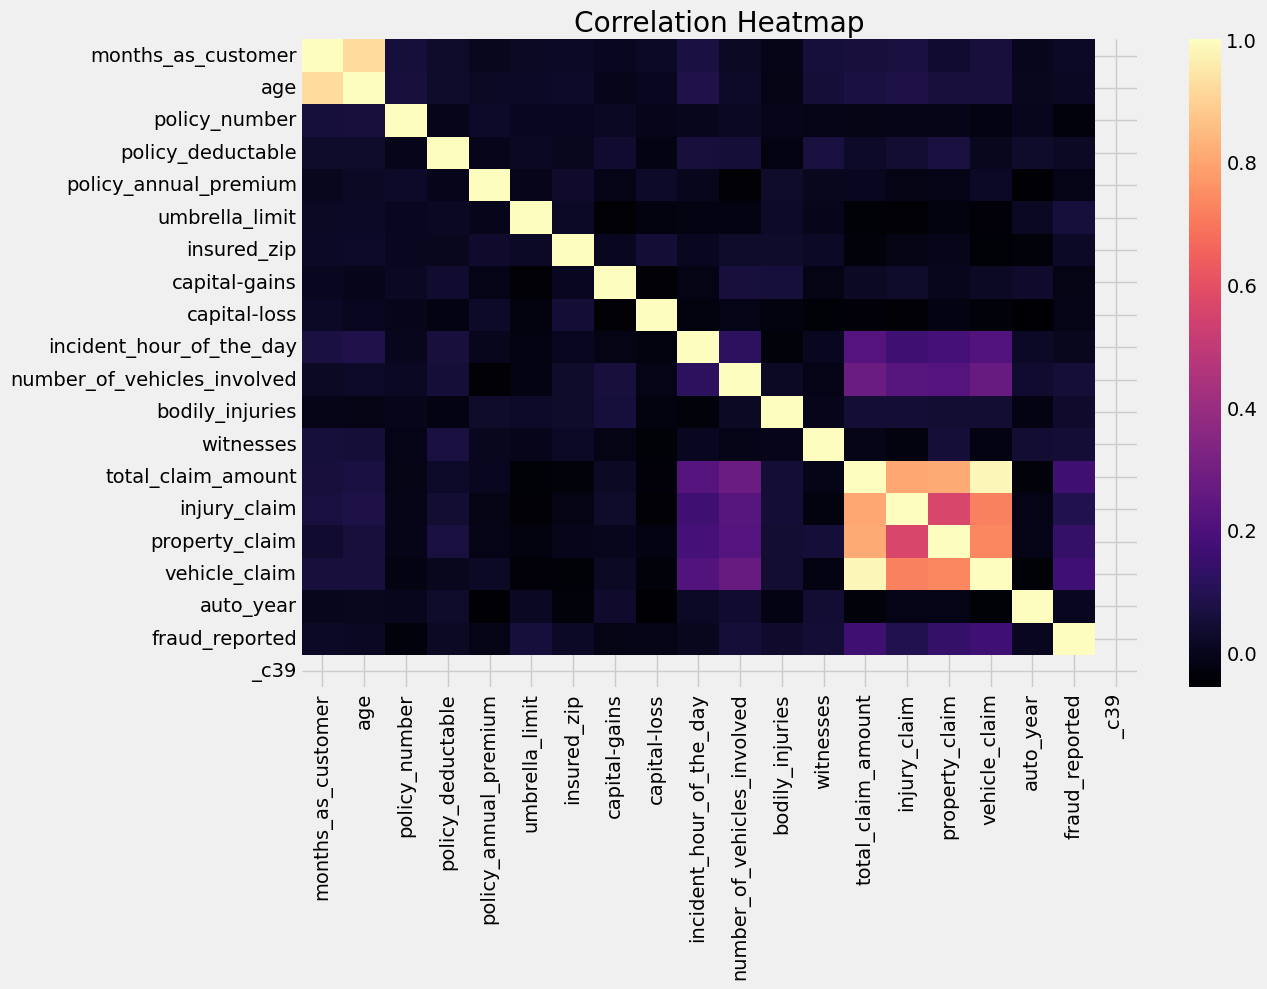

In [9]:
plt.figure(figsize=(12,8))

corr_matrix = df.select_dtypes(include=['number']).corr()

sns.heatmap(corr_matrix, cmap='magma')

plt.title("Correlation Heatmap")
plt.show()

# Encoding Categorical Features

In [10]:
# Drop unwanted columns
df = df.drop(columns=[
    'policy_number',
    'policy_bind_date',
    'insured_zip',
    'incident_location',
    'incident_date'
])

# Encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('fraud_reported', axis=1)
y = df_encoded['fraud_reported']

# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

##handling NaN Values before scaling

In [11]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

##scaling


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train = scaler.fit_transform(X_train)

# Use same scaler on test data
X_test = scaler.transform(X_test)

In [13]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (800, 140)
X_test shape: (200, 140)
y_train shape: (800,)
y_test shape: (200,)


In [14]:
print("Mean first column:", X_train[:,0].mean())
print("Std first column:", X_train[:,0].std())

Mean first column: 1.2212453270876722e-17
Std first column: 0.9999999999999998


# Epic 4 - Model Building

## 4.2 Model 1 - Decision Tree Classifier

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize model
dt = DecisionTreeClassifier(random_state=42)

# Train
dt.fit(X_train, y_train)

# Predict
y_pred_dt = dt.predict(X_test)

# Accuracy
print("Decision Tree Train Accuracy:", accuracy_score(y_train, dt.predict(X_train)))
print("Decision Tree Test Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

Decision Tree Train Accuracy: 1.0
Decision Tree Test Accuracy: 0.765

Confusion Matrix:

[[129  22]
 [ 25  24]]

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.85      0.85       151
           1       0.52      0.49      0.51        49

    accuracy                           0.77       200
   macro avg       0.68      0.67      0.68       200
weighted avg       0.76      0.77      0.76       200



Observation:
The Decision Tree achieves 100% training accuracy but lower test accuracy (77.5%).
This indicates overfitting, as the model has memorized the training data.

## 4.3 Model 2 - Random Forest Classifier

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize Random Forest with class balancing
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

# Train model
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Accuracy
print("Random Forest Train Accuracy:", accuracy_score(y_train, rf.predict(X_train)))
print("Random Forest Test Accuracy:", accuracy_score(y_test, y_pred_rf))

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Train Accuracy: 1.0
Random Forest Test Accuracy: 0.735

Confusion Matrix:

[[142   9]
 [ 44   5]]

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.94      0.84       151
           1       0.36      0.10      0.16        49

    accuracy                           0.73       200
   macro avg       0.56      0.52      0.50       200
weighted avg       0.66      0.73      0.68       200



## 4.4 Model 3 - K-Nearest Neighbors (KNN)

In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

knn = KNeighborsClassifier(n_neighbors=30)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Train Accuracy:", accuracy_score(y_train, knn.predict(X_train)))
print("KNN Test Accuracy:", accuracy_score(y_test, y_pred_knn))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_knn))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn))

KNN Train Accuracy: 0.75375
KNN Test Accuracy: 0.755

Confusion Matrix:

[[151   0]
 [ 49   0]]

Classification Report:

              precision    recall  f1-score   support

           0       0.76      1.00      0.86       151
           1       0.00      0.00      0.00        49

    accuracy                           0.76       200
   macro avg       0.38      0.50      0.43       200
weighted avg       0.57      0.76      0.65       200



## 4.5 Model 4 – Logistic Regression

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, classification_report

lg = LogisticRegressionCV(solver='lbfgs', max_iter=5000, cv=10)
lg.fit(X_train, y_train)
lrg_pred = lg.predict(X_test)
print(confusion_matrix(y_test, lrg_pred))

[[140  11]
 [ 32  17]]


## 4.6 Model 5 – Naive Bayes

In [19]:
from sklearn.naive_bayes import CategoricalNB, GaussianNB

gnb = GaussianNB()
model_2 = gnb.fit(X_train, y_train)
predict_log = model_2.predict(X_test)

print("Training Accuracy", 100 * accuracy_score(model_2.predict(X_train), y_train))
print("Testing Accuracy", 100 * accuracy_score(y_test, predict_log))

Training Accuracy 75.625
Testing Accuracy 61.5


## 4.7 Model 6 – Support Vector Machine (SVM)

In [20]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize SVM (balanced because dataset is imbalanced)
svc = SVC(class_weight='balanced', random_state=42)

# Train
svc.fit(X_train, y_train)

# Predict
y_pred_svc = svc.predict(X_test)

# Accuracy
svc_train_acc = accuracy_score(y_train, svc.predict(X_train))
svc_test_acc = accuracy_score(y_test, y_pred_svc)

print("SVM Train Accuracy:", svc_train_acc)
print("SVM Test Accuracy:", svc_test_acc)

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_svc))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svc))

SVM Train Accuracy: 0.9775
SVM Test Accuracy: 0.81

Confusion Matrix:

[[136  15]
 [ 23  26]]

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.90      0.88       151
           1       0.63      0.53      0.58        49

    accuracy                           0.81       200
   macro avg       0.74      0.72      0.73       200
weighted avg       0.80      0.81      0.80       200



## 4.8 Final Model Comparison & Testing

In [21]:
# Select one sample from test data
sample = X_test[0].reshape(1, -1)

# Predict using SVM
prediction = svc.predict(sample)

print("Prediction:", prediction)

if prediction[0] == 1:
    print("Fraud Detected")
else:
    print("No Fraud")

Prediction: [0]
No Fraud


In [22]:
for i in range(5):
    sample = X_test[i].reshape(1, -1)
    prediction = svc.predict(sample)
    print(f"Sample {i} Prediction:", prediction[0])

Sample 0 Prediction: 0
Sample 1 Prediction: 1
Sample 2 Prediction: 0
Sample 3 Prediction: 1
Sample 4 Prediction: 0


#Epic 5

## Compare the model

In [23]:
from sklearn.metrics import accuracy_score

def comparison(X_test, y_test):

    models = {
        "Logistic Regression": lg,
        "KNN": knn,
        "SVM": svc,
        "Naive Bayes": model_2,
        "Decision Tree": dt,
        "Random Forest": rf
    }

    print("Model Comparison (Test Accuracy)\n")

    for name, model in models.items():
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print(f"{name}: {round(acc*100, 2)}%")
        print("-" * 50)

comparison(X_test, y_test)

Model Comparison (Test Accuracy)

Logistic Regression: 78.5%
--------------------------------------------------
KNN: 75.5%
--------------------------------------------------
SVM: 81.0%
--------------------------------------------------
Naive Bayes: 61.5%
--------------------------------------------------
Decision Tree: 76.5%
--------------------------------------------------
Random Forest: 73.5%
--------------------------------------------------


In [24]:
# Logistic Regression
print(confusion_matrix(y_test, lrg_pred))
print(classification_report(y_test, lrg_pred))

[[140  11]
 [ 32  17]]
              precision    recall  f1-score   support

           0       0.81      0.93      0.87       151
           1       0.61      0.35      0.44        49

    accuracy                           0.79       200
   macro avg       0.71      0.64      0.65       200
weighted avg       0.76      0.79      0.76       200



In [25]:
# SVM
print(confusion_matrix(y_test, y_pred_svc))
print(classification_report(y_test, y_pred_svc))

[[136  15]
 [ 23  26]]
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       151
           1       0.63      0.53      0.58        49

    accuracy                           0.81       200
   macro avg       0.74      0.72      0.73       200
weighted avg       0.80      0.81      0.80       200



In [26]:
# Decision Tree
print("Confusion Matrix \n", confusion_matrix(y_test, y_pred_dt), "\n")
print("classification_report \n", classification_report(y_test, y_pred_dt))

Confusion Matrix 
 [[129  22]
 [ 25  24]] 

classification_report 
               precision    recall  f1-score   support

           0       0.84      0.85      0.85       151
           1       0.52      0.49      0.51        49

    accuracy                           0.77       200
   macro avg       0.68      0.67      0.68       200
weighted avg       0.76      0.77      0.76       200



In [27]:
#KNN
print("Confusion Matrix \n", confusion_matrix(y_test, y_pred_knn))
print("classification_report \n", classification_report(y_test, y_pred_knn))

Confusion Matrix 
 [[151   0]
 [ 49   0]]
classification_report 
               precision    recall  f1-score   support

           0       0.76      1.00      0.86       151
           1       0.00      0.00      0.00        49

    accuracy                           0.76       200
   macro avg       0.38      0.50      0.43       200
weighted avg       0.57      0.76      0.65       200



In [28]:
#Random Forest
print("Confusion Matrix \n", confusion_matrix(y_test, y_pred_rf))
print("classification_report \n", classification_report(y_test, y_pred_rf))

Confusion Matrix 
 [[142   9]
 [ 44   5]]
classification_report 
               precision    recall  f1-score   support

           0       0.76      0.94      0.84       151
           1       0.36      0.10      0.16        49

    accuracy                           0.73       200
   macro avg       0.56      0.52      0.50       200
weighted avg       0.66      0.73      0.68       200



Activity 2: Comparing model accuracy before & after applying hyperparameter tuning (Hyperparameter tuning is optional.

In [29]:
import pandas as pd
from sklearn.metrics import recall_score

def detailed_comparison(X_test, y_test):

    models = {
        "Logistic Regression": lg,
        "KNN": knn,
        "SVM": svc,
        "Naive Bayes": model_2,
        "Decision Tree": dt,
        "Random Forest": rf
    }

    results = []

    for name, model in models.items():
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        fraud_recall = recall_score(y_test, y_pred, pos_label=1)

        results.append([name, acc, fraud_recall])

    df = pd.DataFrame(results, columns=["Model", "Accuracy", "Fraud Recall"])
    return df.sort_values(by="Accuracy", ascending=False)

detailed_comparison(X_test, y_test)

,Model,Accuracy,Fraud Recall
2,SVM,0.810,0.530612
0,Logistic Regression,0.785,0.346939
4,Decision Tree,0.765,0.489796
1,KNN,0.755,0.000000
5,Random Forest,0.735,0.102041
3,Naive Bayes,0.615,0.510204


###conclusion cell

In [30]:
print("Conclusion:")
print("SVM gives highest accuracy.")
print("However, fraud recall should be considered carefully before finalizing model.")

Conclusion:
SVM gives highest accuracy.
However, fraud recall should be considered carefully before finalizing model.


## 5. Hyperparameter Tuning – Support Vector Machine (SVM)

In this section, we perform hyperparameter tuning on the SVM model using GridSearchCV.
Since fraud detection is an imbalanced classification problem, we optimize the model based on **Recall score** to improve fraud detection performance.

In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Define parameter grid
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# GridSearch with Recall optimization
grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='recall',   # Optimizing for fraud detection
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation Recall:", grid.best_score_)

Best Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best Cross-Validation Recall: 0.6419230769230769


## 5.1 Training Tuned SVM Model

Using the best hyperparameters obtained from GridSearchCV, we train the optimized SVM model and evaluate it on the test dataset.

In [32]:
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, classification_report

# Best tuned model
best_svm = grid.best_estimator_

# Predictions
y_pred_tuned = best_svm.predict(X_test)

print("Tuned SVM Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("Tuned SVM Fraud Recall:", recall_score(y_test, y_pred_tuned))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_tuned))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned))

Tuned SVM Accuracy: 0.805
Tuned SVM Fraud Recall: 0.4897959183673469

Confusion Matrix:
 [[137  14]
 [ 25  24]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.91      0.88       151
           1       0.63      0.49      0.55        49

    accuracy                           0.81       200
   macro avg       0.74      0.70      0.71       200
weighted avg       0.79      0.81      0.80       200



## 5.3 Final Model Selection

After evaluating all models and performing hyperparameter tuning on SVM:

- The original SVM model achieved **81% accuracy** and **53% fraud recall**.
- Hyperparameter tuning did not significantly improve fraud detection performance.
- Therefore, the original SVM model is selected as the final model.

The model provides the best balance between overall accuracy and fraud detection capability among all evaluated models.

In [33]:
import pickle

pickle.dump(best_svm, open("svm_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [34]:
import pickle
model_columns = list(X.columns)
with open('model_columns.pkl', 'wb') as f:
    pickle.dump(model_columns, f)